In [1]:
import pathlib
from os import path, getcwd, chdir

import numpy as np
from tqdm import tqdm

chdir(r'C:\Users\IanFu\Desktop\~1_CURRENT\efsprapy\01-analysis\ftp_safir_comparison')


def read_data(parent_dir: pathlib.Path) -> (list, list):
    folders = [item for item in parent_dir.iterdir() if item.is_dir()]
    folders.sort()
    failure_prob_doct = dict()
    for folder in tqdm(folders):
        fp_output = folder / f'{folder.name}_out.csv'
        try:
            assert path.exists(fp_output), f'file does not exist {fp_output}'
        except AssertionError:
            return None
        mcs_output = np.genfromtxt(fp_output, delimiter=",", skip_header=1)

        N = np.shape(mcs_output)[0]

        # find all iterations that ignition occurred
        t_ig_ftp = mcs_output[:, 2]
        P_ig = sum(np.logical_and(t_ig_ftp > 0, t_ig_ftp < np.inf)) / N

        failure_prob_doct[folder.name] = P_ig
    return failure_prob_doct


data = dict(
    ftp_20mm=read_data(pathlib.Path(getcwd(), 'ftp_20mm')),
    ftp_40mm=read_data(pathlib.Path(getcwd(), 'ftp_40mm')),
    safir_20mm=read_data(pathlib.Path(getcwd(), 'safir_20mm')),
    safir_40mm=read_data(pathlib.Path(getcwd(), 'safir_40mm')),
)

100%|██████████| 1/1 [00:00<00:00, 63.64it/s]


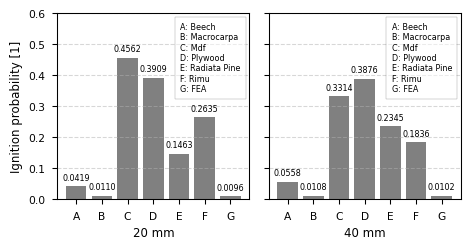

In [56]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-paper')

fig, (ax1, ax2) = plt.subplots(figsize=(5, 2.7), ncols=2, dpi=96, sharey=True)

bars1_1 = ax1.bar(data['ftp_20mm'].keys(), data['ftp_20mm'].values(), color='grey')
bars1_2 = ax1.bar(len(bars1_1), data['safir_20mm']['safir_20mm'], color='grey')
legend_text = '\n'.join(
    f'{"ABCDEFG"[i]}: {name.replace("_", " ").title()}' for i, name in enumerate((data['ftp_20mm'].keys())))
legend_text += '\nG: FEA'
ax1.text(0.64, 0.95, legend_text, ha='left', va='top', color='k', fontsize=6, transform=ax1.transAxes,
         bbox=dict(facecolor='white', alpha=0.5))
ax1.set_ylabel('Ignition probability [1]')
ax1.set_xlabel('20 mm')
ax1.set_xticks(range(len(data['ftp_20mm']) + 1))
ax1.set_xticklabels(['ABCDEFGH'[i] for i in range(len(data['ftp_20mm']) + 1)], rotation=0)
ax1.bar_label(bars1_1, fmt='%.4f', padding=3, fontsize=6)
ax1.bar_label(bars1_2, fmt='%.4f', padding=3, fontsize=6)
ax1.grid(True, linestyle='--', alpha=0.5, axis='y')

bars2_1 = ax2.bar(data['ftp_40mm'].keys(), data['ftp_40mm'].values(), color='grey')
bars2_2 = ax2.bar(len(bars2_1), data['safir_40mm']['safir_40mm'], color='grey')
legend_text = '\n'.join(
    f'{"ABCDEFG"[i]}: {name.replace("_", " ").title()}' for i, name in enumerate((data['ftp_40mm'].keys())))
legend_text += '\nG: FEA'
ax2.text(0.64, 0.95, legend_text, ha='left', va='top', color='k', fontsize=6, transform=ax2.transAxes,
         bbox=dict(facecolor='white', alpha=0.5))
ax2.set_xlabel('40 mm')
ax2.set_xticks(range(len(data['ftp_40mm']) + 1))
ax2.set_xticklabels(['ABCDEFGH'[i] for i in range(len(data['ftp_40mm']) + 1)], rotation=0)
ax2.bar_label(bars2_1, fmt='%.4f', padding=3, fontsize=6)
ax2.bar_label(bars2_2, fmt='%.4f', padding=3, fontsize=6)
ax2.grid(True, linestyle='--', alpha=0.5, axis='y')

ax2.set_ylim(0, 0.6)

fig.tight_layout()

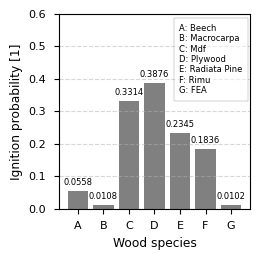

In [39]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-paper')

fig, ax2 = plt.subplots(figsize=(2.7, 2.7), dpi=100)

bars2 = ax2.bar(data['ftp_40mm'].keys(), data['ftp_40mm'].values(), color='grey')
bars3 = ax2.bar(len(bars2), data['safir_40mm']['safir_40mm'], color='grey')
legend_text = '\n'.join(
    f'{"ABCDEFG"[i]}: {name.replace("_", " ").title()}' for i, name in enumerate((data['ftp_40mm'].keys())))
legend_text += '\nG: FEA'
ax2.text(0.63, 0.95, legend_text, ha='left', va='top', color='k', fontsize=6, transform=ax2.transAxes,
         bbox=dict(facecolor='white', alpha=0.5))
ax2.set_ylabel('Ignition probability [1]')
# ax2.set_xlabel('Wood species')
ax2.set_xticks(range(len(data['ftp_40mm']) + 1))
ax2.set_xticklabels(['ABCDEFGH'[i] for i in range(len(data['ftp_40mm']) + 1)], rotation=0)
ax2.bar_label(bars2, fmt='%.4f', padding=3, fontsize=6)
ax2.bar_label(bars3, fmt='%.4f', padding=3, fontsize=6)
ax2.grid(True, linestyle='--', alpha=0.5, axis='y')

ax2.set_ylim(0, 0.6)

fig.tight_layout()

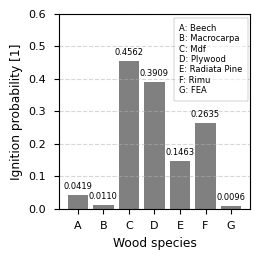

In [40]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-paper')

fig, ax2 = plt.subplots(figsize=(2.7, 2.7), dpi=100)

bars2 = ax2.bar(data['ftp_20mm'].keys(), data['ftp_20mm'].values(), color='grey')
bars3 = ax2.bar(len(bars2), data['safir_20mm']['safir_20mm'], color='grey')
legend_text = '\n'.join(
    f'{"ABCDEFG"[i]}: {name.replace("_", " ").title()}' for i, name in enumerate((data['ftp_20mm'].keys())))
legend_text += '\nG: FEA'
ax2.text(0.63, 0.95, legend_text, ha='left', va='top', color='k', fontsize=6, transform=ax2.transAxes,
         bbox=dict(facecolor='white', alpha=0.5))
ax2.set_ylabel('Ignition probability [1]')
# ax2.set_xlabel('Wood species')
ax2.set_xticks(range(len(data['ftp_20mm']) + 1))
ax2.set_xticklabels(['ABCDEFGH'[i] for i in range(len(data['ftp_20mm']) + 1)], rotation=0)
ax2.bar_label(bars2, fmt='%.4f', padding=3, fontsize=6)
ax2.bar_label(bars3, fmt='%.4f', padding=3, fontsize=6)
ax2.grid(True, linestyle='--', alpha=0.5, axis='y')

ax2.set_ylim(0, 0.6)

fig.tight_layout()

In [60]:
import pprint

pprint.pprint(data)

{'ftp_20mm': {'beech': np.float64(0.0419),
              'macrocarpa': np.float64(0.011),
              'mdf': np.float64(0.4562),
              'plywood': np.float64(0.3909),
              'radiata_pine': np.float64(0.1463),
              'rimu': np.float64(0.2635)},
 'ftp_40mm': {'beech': np.float64(0.0558),
              'macrocarpa': np.float64(0.0108),
              'mdf': np.float64(0.3314),
              'plywood': np.float64(0.3876),
              'radiata_pine': np.float64(0.2345),
              'rimu': np.float64(0.1836)},
 'safir_20mm': {'safir_20mm': np.float64(0.0096)},
 'safir_40mm': {'safir_40mm': np.float64(0.0102)}}
